# Simple model with Flow Matching

Attempting to do the same thing as in `simple_model.ipynb`, but using Flow Matching instead of MCMC sampling. 

In [2]:
import sys
sys.path.append('..')

from src.simulator import BurstSimulator, Model
from src.flow_matching.probability_path import Sampleable, LinearConditionalProbabilityPath, GuidedLinearProbabilityPath, ConditionalProbabilityPath
from src.flow_matching.training import ConditionalFlowMatchingTrainer, GuidedConditionalFlowMatchingTrainer
from src.flow_matching.integration import EulerODESolver
from src.flow_matching.models import MLPVectorField, MLPGuidedVectorField


import numpy as np
import matplotlib.cm as cm
from matplotlib import pyplot as plt
import torch
import torch.distributions as D

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')

In [3]:
# Several plotting utility functions
def hist2d_samples(samples, bins: int = 200, percentile: int = 99, **kwargs):
    H, _, _ = np.histogram2d(samples[:, 0], samples[:, 1], bins=bins)

    # Determine color normalization based on the 99th percentile
    cmax = np.percentile(H, percentile)
    cmin = 0.0
    norm = cm.colors.Normalize(vmax=cmax, vmin=cmin)

    # Plot using imshow for more control
    plt.imshow(H.T, origin='lower', norm=norm, **kwargs)

def record_every(num_timesteps: int, record_every: int) -> torch.Tensor:
    """
    Compute the indices to record in the trajectory given a record_every parameter
    """
    if record_every == 1:
        return torch.arange(num_timesteps)
    return torch.cat(
        [
            torch.arange(0, num_timesteps - 1, record_every),
            torch.tensor([num_timesteps - 1]),
        ]
    )

# Example from MIT Lab two

Modified example from the MIT course where they transform an isotropic Gaussian into an arbitrary distribution using a linear conditional probability path. 

In [19]:
class Gaussian(torch.nn.Module, Sampleable):
    """
    Multivariate Gaussian distribution
    """
    def __init__(self, mean: torch.Tensor, cov: torch.Tensor):
        """
        mean: shape (dim,)
        cov: shape (dim,dim)
        """
        super().__init__()
        self.register_buffer("mean", mean)
        self.register_buffer("cov", cov)

    @property
    def dim(self) -> int:
        return self.mean.shape[0]

    @property
    def distribution(self):
        return D.MultivariateNormal(self.mean, self.cov, validate_args=False)

    def sample(self, num_samples) -> torch.Tensor:
        return self.distribution.sample((num_samples,))

    def log_density(self, x: torch.Tensor):
        return self.distribution.log_prob(x).view(-1, 1)

    @classmethod
    def isotropic(cls, dim: int, std: float) -> "Gaussian":
        mean = torch.zeros(dim)
        cov = torch.eye(dim) * std ** 2
        return cls(mean, cov)
    
class CheckerboardSampleable(Sampleable):
    """
    Checkboard-esque distribution
    """
    def __init__(self, device: torch.device, grid_size: int = 3, scale=5.0):
        """
        Args:
            noise: standard deviation of Gaussian noise added to the data
        """
        self.grid_size = grid_size
        self.scale = scale
        self.device = device

    @property
    def dim(self) -> int:
        return 2

    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Args:
            num_samples: number of samples to generate
        Returns:
            torch.Tensor: shape (num_samples, 3)
        """
        grid_length = 2 * self.scale / self.grid_size
        samples = torch.zeros(0,2).to(device)
        while samples.shape[0] < num_samples:
            # Sample num_samples
            new_samples = (torch.rand(num_samples,2).to(self.device) - 0.5) * 2 * self.scale
            x_mask = torch.floor((new_samples[:,0] + self.scale) / grid_length) % 2 == 0 # (bs,)
            y_mask = torch.floor((new_samples[:,1] + self.scale) / grid_length) % 2 == 0 # (bs,)
            accept_mask = torch.logical_xor(~x_mask, y_mask)
            samples = torch.cat([samples, new_samples[accept_mask]], dim=0)
        return samples[:num_samples]

In [20]:
# Construct conditional probability path
path = LinearConditionalProbabilityPath(
    p_simple = Gaussian.isotropic(dim=2, std=1.0),
    p_data = CheckerboardSampleable(device, grid_size=4)
).to(device)

# Construct learnable vector field
linear_flow_model = MLPVectorField(dim=2, hiddens=[64,64,64,64])

# Construct trainer
trainer = ConditionalFlowMatchingTrainer(path, linear_flow_model)
losses = trainer.train(num_epochs=10000, device=device, lr=1e-3, batch_size=2000)


Training model with size: 0.049 MiB


0it [00:00, ?it/s]

Epoch 1, loss: 18.313: : 1it [00:00,  9.64it/s]

torch.Size([]) torch.Size([2000]) 2000 tensor([ 0.8402, -3.8690])


Epoch 9999, loss: 7.940: : 10000it [02:19, 71.48it/s]


100%|██████████| 99/99 [00:05<00:00, 19.66it/s]


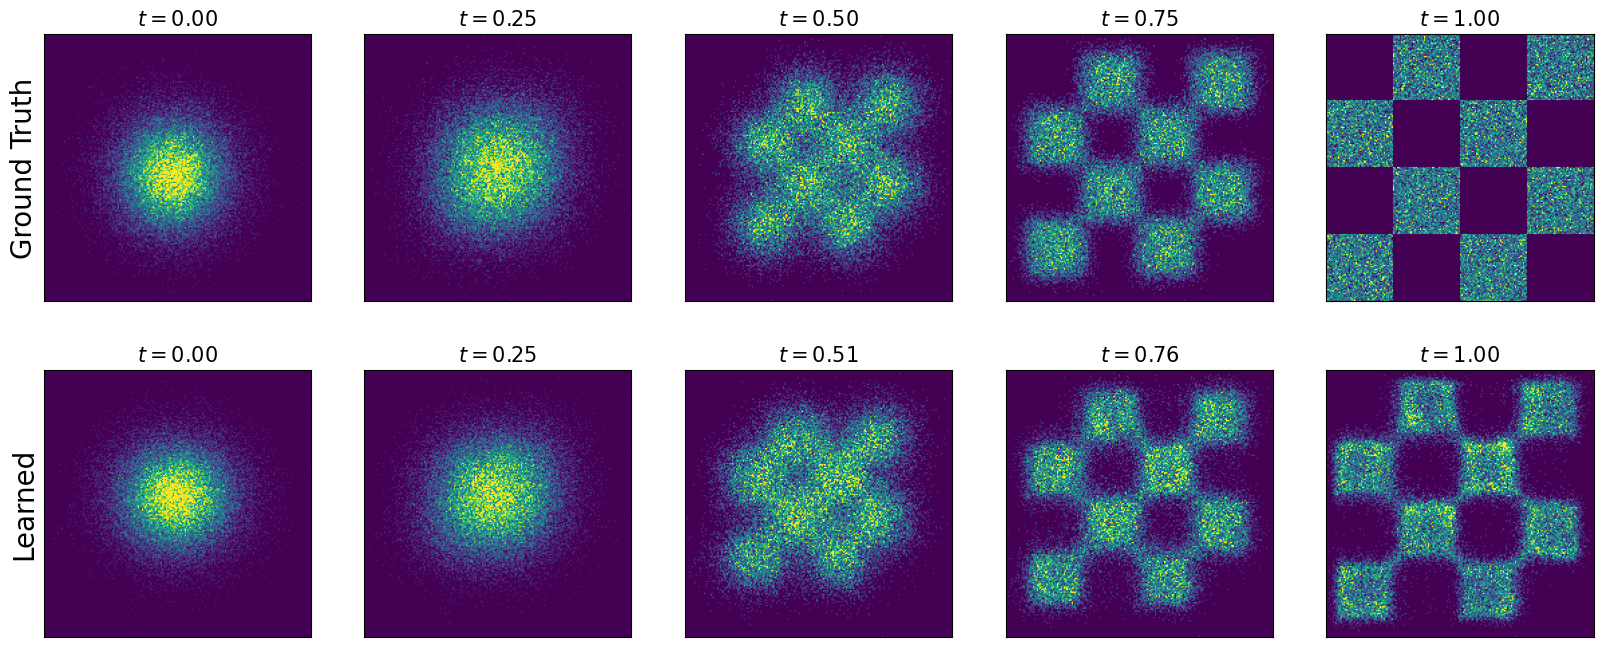

In [ ]:
from src.flow_matching.integration import LearnedVectorFieldODE

num_marginals = 5    # number of snapshots to plot
num_samples = 50000  # number of samples per snapshot 

plt.figure(figsize=(20,8))

# -------------------------------------------- #
#        Plotting Ground-Truth Marginals       #
# -------------------------------------------- #

ts = torch.linspace(0.0, 1.0, num_marginals).to(device)

for idx, t in enumerate(ts):

    tt = t.view(1,1).expand(num_samples, 1)
    xts = path.sample_marginal_path(tt)

    plt.subplot(2, num_marginals, idx + 1)
    hist2d_samples(xts)

    plt.xticks([])
    plt.yticks([])
    plt.title(f'$t={t.item():.2f}$', fontsize=15)

    plt.ylabel("Ground Truth", fontsize=20) if idx == 0 else None

# --------------------------------------------  #
#  Plotting Marginals of Learned Vector Field   #
# -------------------------------------------   #

# initialize ODE solver
ode = LearnedVectorFieldODE(linear_flow_model)
simulator = EulerODESolver(ode)
ts = torch.linspace(0,1,100).to(device)

# solve / simulate ODE from x0
x0 = path.p_simple.sample(num_samples)
xts = simulator.solve_with_trajectory(x0, ts.view(1,-1,1).expand(num_samples,-1,1))

# save only num_marginal snapshots of the trajectory
record_every_idxs = record_every(len(ts), len(ts) // (num_marginals - 1))
xts = xts[:,record_every_idxs,:]

plot_idx = idx + 1

# plot the snapshots
for idx in range(xts.shape[1]):
    xx = xts[:,idx,:]

    plt.subplot(2, num_marginals, plot_idx + idx + 1)
    hist2d_samples(xx)
    plt.xticks([])
    plt.yticks([])

    tt = ts[record_every_idxs[idx]]
    plt.title(f'$t={tt.item():.2f}$', fontsize=15)
    plt.ylabel("Learned", fontsize=20) if idx == 0 else None

plt.show()

# Example CFM for SBI
We modify the example above to transform a uniform prior with enforced order to a delta function posterior centered on [`true_t0_1`, `true_t0_2`]. 

In [4]:

# Samplelable prior for t0_1 and t0_2
class Prior(Sampleable):
    @property
    def dim(self) -> int:
        return 2

    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Args:
            num_samples: number of samples to generate
        Returns:
            torch.Tensor: shape (num_samples, 2)
        """
        t0_samples, _ = torch.sort(torch.rand((num_samples, self.dim)), dim=1)
        return t0_samples.to(device)

# Samplelable posterior 
class Posterior(Sampleable):

    """
    This is now for a given datapoint, so just samples true_t0_1, true_t0_2.
    Essentially a delta function.
    """
    @property
    def dim(self) -> int:
        return 2

    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Args:
            num_samples: number of samples to generate
        Returns:
            torch.Tensor: shape (num_samples, 2)
        """
        t0_1 = 0.1 * torch.ones((num_samples, 1))
        t0_2 = 0.6 * torch.ones((num_samples, 1))
        return torch.cat((t0_1, t0_2), dim=1)

# construct conditional probability path
path = LinearConditionalProbabilityPath(
    p_simple = Prior(),
    p_data = Posterior()
).to(device)

# construct learnable vector field
linear_flow_model = MLPVectorField(dim=2, hiddens=[64,64,64,64])

# construct trainer
trainer = ConditionalFlowMatchingTrainer(path, linear_flow_model)
losses = trainer.train(num_epochs=1000, device=device, lr=1e-3, batch_size=2000)

Training model with size: 0.049 MiB


Epoch 4, loss: 0.145: : 5it [00:00, 23.31it/s]

torch.Size([]) torch.Size([2000]) 2000 tensor([0.1000, 0.6000])


Epoch 999, loss: 0.004: : 1000it [00:16, 61.24it/s]


100%|██████████| 99/99 [00:04<00:00, 19.91it/s]


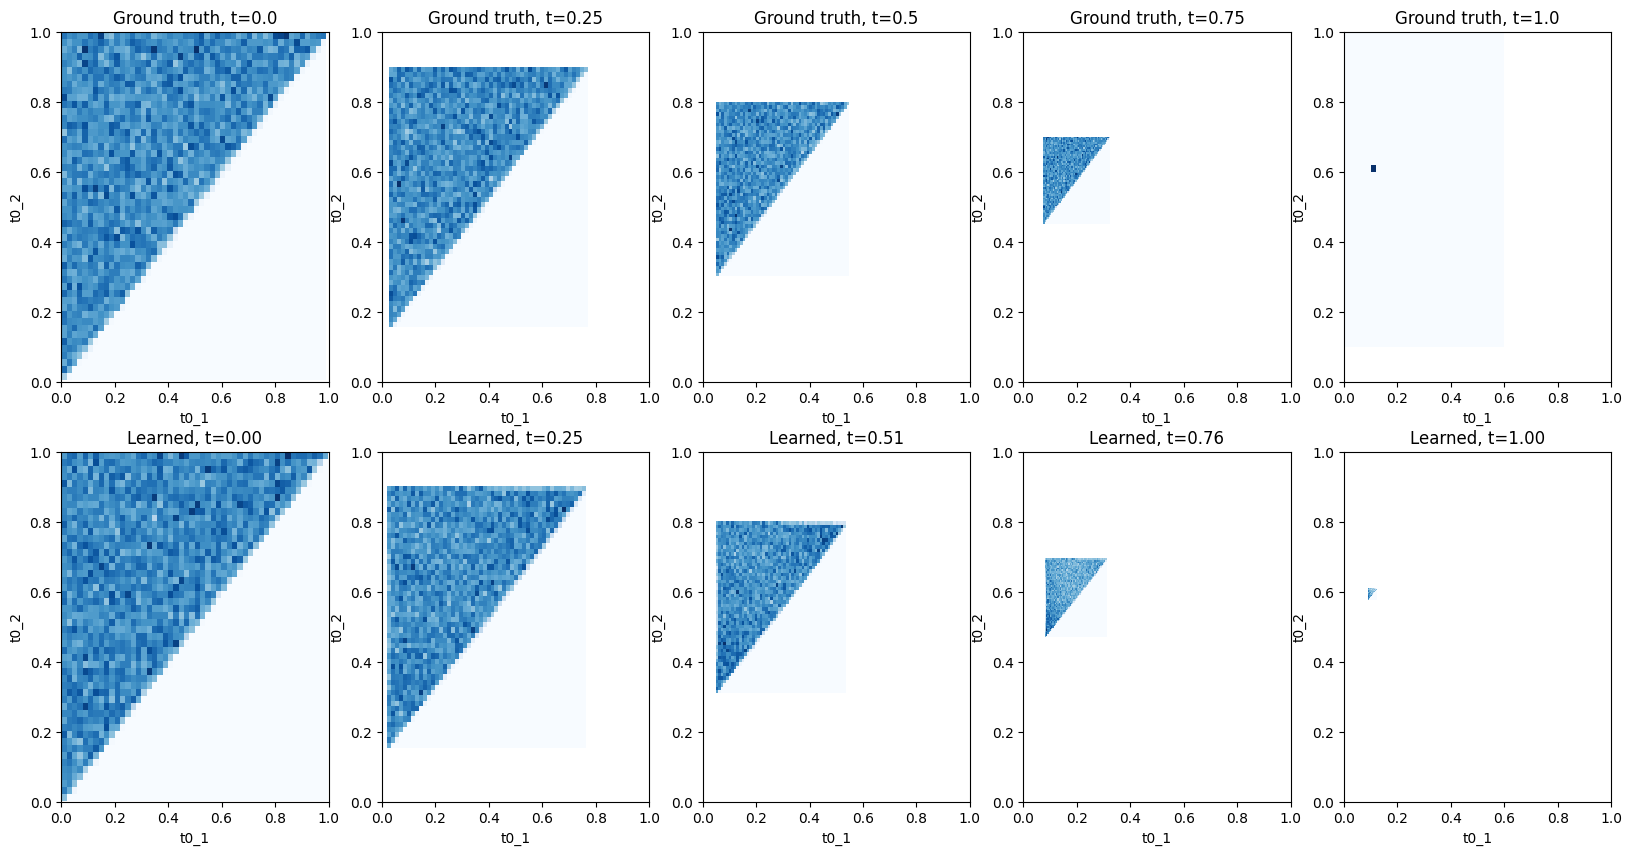

In [5]:
from src.flow_matching.integration import LearnedVectorFieldODE

num_samples = 50000  # number of samples per snapshot
num_marginals = 5    # number of snapshots to plot

plt.figure(figsize=(20,10))

# ----------------------------- #
# Graph Ground-Truth Marginals  #
# ----------------------------- #
ts = torch.linspace(0.0, 1.0, num_marginals).to(device)
for idx, t in enumerate(ts):
    tt = t.view(1,1).expand(num_samples,1)
    xts = path.sample_marginal_path(tt)

    plt.subplot(2, num_marginals, idx + 1)
    plt.hist2d(x=xts[:, 0], y=xts[:, 1], bins=50, cmap='Blues')

    plt.title(f"Ground truth, t={t.item()}")
    plt.xlabel(f"t0_1")
    plt.ylabel(f"t0_2")

    plt.xlim(0, 1)
    plt.ylim(0, 1)

# -----------------------------------------#
# Graph Marginals of Learned Vector Field  #
# -----------------------------------------#

# initialize ODE solver
ode = LearnedVectorFieldODE(linear_flow_model)
simulator = EulerODESolver(ode)
ts = torch.linspace(0,1,100).to(device)

# solve / simulate ode starting from x0
x0 = path.p_simple.sample(num_samples)
xts = simulator.solve_with_trajectory(x0, ts.view(1,-1,1).expand(num_samples,-1,1))

# only save num_marginal snapshots
record_every_idxs = record_every(len(ts), len(ts) // (num_marginals - 1))
xts = xts[:,record_every_idxs,:]

subplot_idx = idx + 1 # for plotting 

for idx in range(xts.shape[1]):
    xx = xts[:,idx,:]
    t = ts.cpu()[record_every_idxs[idx]]

    plt.subplot(2, num_marginals, subplot_idx + idx + 1)
    
    plt.hist2d(x=xx[:, 0], y=xx[:, 1], bins=50, cmap='Blues')
    plt.title(f"Learned, t={t:.2f}")
    plt.xlabel(f"t0_1")
    plt.ylabel(f"t0_2")

    plt.xlim(0, 1)
    plt.ylim(0, 1)

plt.show()

# Adding guiding with simulated data for fixed parameters
Now want to do guided flow matching, meaning the transformation is guided by a sample from the simulated dataset. This means during training we train using sample pairs (p, d) where p are the parameters and d is the corresponding simulated data generated with the simulator with input p. The input of the network in the end will be prior sample p_r and simulated data. The output of the solved ODE with the learned vector field is a sample from the posterior. We have to change several functions to accomodate training pairs (p, d). 

In [ ]:
# Generate a bunch of data from prior and simulator, save the light curve and the params or do this on the spot?
# For now, fix all params, infer peak times 

# Samplelable prior for t0_1 and t0_2
class Prior(Sampleable):
    @property
    def dim(self) -> int:
        return 2

    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Args:
            num_samples: number of samples to generate
        Returns:
            torch.Tensor: shape (num_samples, 2)
        """
        t0_samples, _ = torch.sort(torch.rand((num_samples, self.dim)), dim=1)
        return t0_samples.to(device)

# Samplelable posterior needs to sample prior and generate simulated data. 
class PairedPosterior(Sampleable):

    """
    Samples z, y ~ p(z)p(y|z), where z=model params, y=simulated data.
    """
    @property
    def dim(self) -> int:
        return 2
    
    def sample(self, num_samples: int, prior=Prior()) -> torch.Tensor:
        """
        Args:
            num_samples: number of samples to generate
        Returns:
            torch.Tensor: shape (num_samples, 2)
        """
        
        # fixed parameters
        N = 2
        time = np.linspace(0, 1.0, 1000)
        amp  = 25.0
        rise = 0.03
        skew = 5
        ybkg = 5.0

        # t0 samples 
        prior_samples = prior.sample((num_samples))

        # generate simulated data from prior samples
        simulation_time_resolution = 100
        simulations = torch.zeros((num_samples, simulation_time_resolution)).to(device)

        for idx in range(num_samples):

            prior_sample = prior_samples[idx]
            
            # parameters of each burst component
            burstparams = {
                't0'   : list(prior_sample.cpu().numpy()),
                'amp'  : [amp, amp],
                'rise' : [rise, rise],
                'skew' : [skew, skew]
            }

            # initialize burst model
            model = Model(
                time=time,
                ncomp=N, 
                burstparams=burstparams, 
                ybkg=ybkg
                )
            
            # generate simulated light curve
            simulator = BurstSimulator(model)
            x_counts = simulator.simulate_burst()

            # reduce light curve time resolution (save every 10th point)
            compressed_x_counts = torch.Tensor(x_counts[::10]) 

            # save to array
            simulations[idx, :] = compressed_x_counts

        return prior_samples, simulations

# Construct conditional probability path
path = GuidedLinearProbabilityPath(
    p_simple = Prior(),# should be Sampleable prior 
    p_data = PairedPosterior() # this should be posterior sample (+ labels, i.e. simulated data, later on)
).to(device)

# dimension is 2 parameters + 1000 datapoints of a simulation
linear_flow_model = MLPGuidedVectorField(dim=2, hiddens=[64, 64, 32, 16], y_dim=100)

In [7]:
# Construct trainer
trainer = GuidedConditionalFlowMatchingTrainer(path, linear_flow_model)
losses = trainer.train(num_epochs=5000, device=device, lr=1e-3, batch_size=200)

Training model with size: 0.051 MiB


Epoch 0, loss: 0.331: : 1it [00:00,  6.31it/s]

torch.Size([]) torch.Size([200]) 200 tensor([0.0930, 0.6568])


Epoch 4999, loss: 0.059: : 5000it [05:51, 14.24it/s]


100%|██████████| 99/99 [00:00<00:00, 126.13it/s]


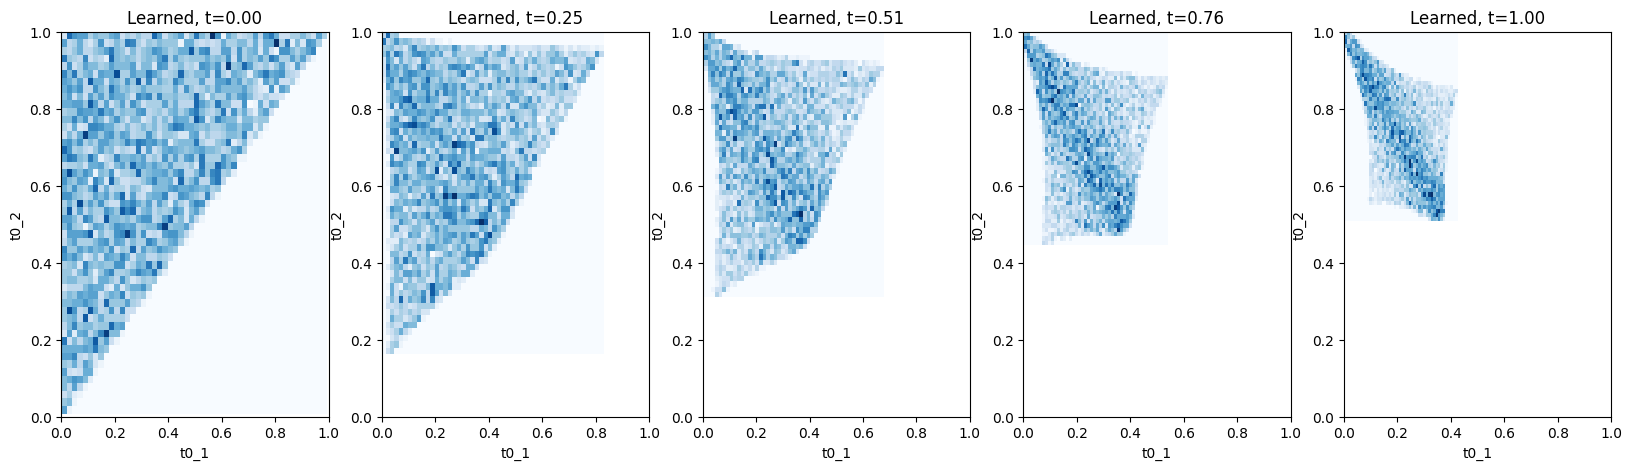

In [13]:
# --------------------------------------------- #
#   Plot Marginal Path of Learned Vector Field  #
# --------------------------------------------- #
class LearnedVectorFieldODE():
    def __init__(self, net: MLPVectorField):
        self.net = net

    def drift_coefficient(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Args:
        - x: (bs, 2) (2 = nr of free parameters)
        - t: (bs, 1)
        - y: (bs, 100) (time_res of lightcurve)
        Returns:
        - u_t^theta(x|y): (bs, 2)
        """
        return self.net(x, t, y)

# generate one instance of simulated data to guide prior samples with

# fixed model parameters (NOTE: Should be same as used during training in PairedPosterior)
N = 2
time = np.linspace(0, 1.0, 1000)
amp  = 25.0
rise = 0.03
skew = 5
ybkg = 5.0

# generate simulated data for one burst
burstparams = {
    't0'   : [0.2, 0.8], # NOTE: this has to obey the prior! (i.e. t0_1 < t0_2 < ... < t0_n)
    'amp'  : [amp, amp],
    'rise' : [rise, rise],
    'skew' : [skew, skew]
}

model = Model(
    time=time,
    ncomp=N, 
    burstparams=burstparams, 
    ybkg=ybkg
    )

simulator = BurstSimulator(model)
x_counts = simulator.simulate_burst()

# reduce light curve time resolution (save every 10th point)
compressed_x_counts = torch.Tensor(x_counts[::10]) 

num_samples = 10000  # number of prior samples to transform 
num_marginals = 5   # number of snapshots

# use same data for all prior samples
simulation_time_resolution = 100
simulations = torch.zeros((num_samples, simulation_time_resolution)).to(device)

for row_nr in range(len(simulations)):
    simulations[row_nr, :] = compressed_x_counts

# Initialize ODE solver
ode = LearnedVectorFieldODE(linear_flow_model)
solver = EulerODESolver(ode)
ts = torch.linspace(0,1,100).to(device)

# simulate ODE starting from x0   # TODO: should simulation be from the one used in training? 
x0 = path.p_simple.sample(num_samples)
xts = solver.solve_with_trajectory(x0, ts.view(1, -1, 1).expand(num_samples,-1,1), y=simulations)

# Only save num_marginals snapshots 
record_every_idxs = record_every(len(ts), len(ts) // (num_marginals - 1))
xts = xts[:,record_every_idxs,:]

# plot snapshots of marginal path
plt.figure(figsize=(20, 5))

for idx in range(xts.shape[1]):
    xx = xts[:,idx,:]
    t = ts.cpu()[record_every_idxs[idx]]

    plt.subplot(1, num_marginals, idx + 1)
    
    plt.hist2d(x=xx[:, 0], y=xx[:, 1], bins=50, cmap='Blues')
    
    plt.title(f"Learned, t={t:.2f}")
    plt.xlabel(f"t0_1")
    plt.ylabel(f"t0_2")

    plt.xlim(0, 1)
    plt.ylim(0, 1)

plt.show()

# TODO: Plot t=1 like a corner plot ?